In [1]:
import torch
import torch.nn.functional as F 
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [4]:
#building dataset

block_size = 3 #context length
X,Y = [],[]
for w in words :
   #print(w)
   context = [0] * block_size
   for ch in w + '.' :
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print (''.join(itos[i] for i in context), '-->', itos[ix])
    context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)



In [5]:
C = torch.randn((27,2))

In [6]:
emb = C[X]

In [7]:
C[X][13,2]

tensor([ 0.9865, -0.3333])

In [8]:
C[1]

tensor([ 0.9865, -0.3333])

In [9]:
w1 = torch.randn((6,100))
b1 = torch.randn(100)

In [10]:
h = torch.tanh(emb.view(-1,6) @ w1 + b1)

In [11]:
h

tensor([[-0.9919,  0.9856, -0.9998,  ...,  0.9224,  0.7502,  0.9830],
        [ 0.6953,  0.9536, -0.9977,  ..., -0.9503,  0.9998, -0.5304],
        [-0.9784,  0.1279, -0.9110,  ..., -0.8312,  1.0000, -0.0658],
        ...,
        [ 0.1768, -0.9974, -0.9982,  ..., -0.9998,  0.9988, -0.2234],
        [ 0.1768,  0.8940,  1.0000,  ...,  1.0000,  0.7978,  0.9983],
        [-0.1137, -0.6108, -1.0000,  ..., -0.9815, -0.9939, -0.9995]])

In [102]:
h.shape

torch.Size([228146, 100])

In [12]:
w2 = torch.randn([100,27])
b2 = torch.randn(27)

In [13]:
logits = h @ w2 + b2

In [105]:
logits.shape

torch.Size([228146, 27])

In [14]:
logits

tensor([[-16.5905, -11.1333,  -9.4728,  ...,  -0.6272,  -3.3531,   2.6681],
        [-11.7065,  -5.5195,  -8.5308,  ...,  -4.9744,   1.6929,   1.7763],
        [ -4.0794,  -6.1882,   7.4998,  ...,   0.0405,  12.8635,   8.7260],
        ...,
        [ -3.6490, -13.7148,   7.3217,  ...,  -4.1003,  16.3917,   5.8055],
        [ -1.5981,   1.3926,  -9.4000,  ..., -10.2156,  -0.4649,  13.1869],
        [  0.8323,   0.1127,  -7.1208,  ...,  16.1389,   7.0250,  -6.5349]])

In [106]:
counts = logits.exp()

In [107]:
prob = counts/counts.sum(1, keepdims=True)

In [19]:
prob.shape

torch.Size([32, 27])

In [108]:
torch.arange(32)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [21]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [ ]:
loss = -prob[torch.arange(32), Y].log().mean()


In [25]:
loss

tensor(17.7362)

In [109]:
F.cross_entropy(logits, Y)

tensor(16.5082)

In [110]:
parameters = [C, w1, b1, w2, b2]
for p in parameters:
    p.requires_grad = True

print(f"Total parameters: {sum(p.nelement() for p in parameters)}")


Total parameters: 3481


In [111]:
lrc = torch.linspace(-3, 0, 1000)
lrs = 10 ** lrc

In [113]:
lri = []
lossi = []
for i in range(1000):
    #contructing mini batch
    ix = torch.randint(0, X.shape[0], (32,))

    # forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ w1 + b1)
    logits = h @ w2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

    lri.append(lr)
    lossi.append(loss.item())


18.310462951660156
15.496922492980957
16.222354888916016
17.786685943603516
15.265555381774902
16.694963455200195
17.15487289428711
15.784737586975098
14.570501327514648
14.2335205078125
17.38821029663086
14.057485580444336
14.57091236114502
15.452474594116211
16.13200569152832
16.34130096435547
17.23456382751465
15.707703590393066
17.5299129486084
18.330642700195312
14.468489646911621
12.926859855651855
17.147533416748047
15.670138359069824
13.821288108825684
14.601541519165039
14.531218528747559
15.257184982299805
16.25407600402832
16.445777893066406
15.645476341247559
16.57423210144043
13.506417274475098
15.604552268981934
15.036541938781738
13.099251747131348
14.756159782409668
13.91839599609375
14.348041534423828
14.865706443786621
12.927350997924805
15.411463737487793
16.923656463623047
17.404571533203125
15.290903091430664
12.314062118530273
17.31773567199707
15.405031204223633
16.45004653930664
14.305641174316406
16.113964080810547
13.158219337463379
18.327802658081055
15.62404

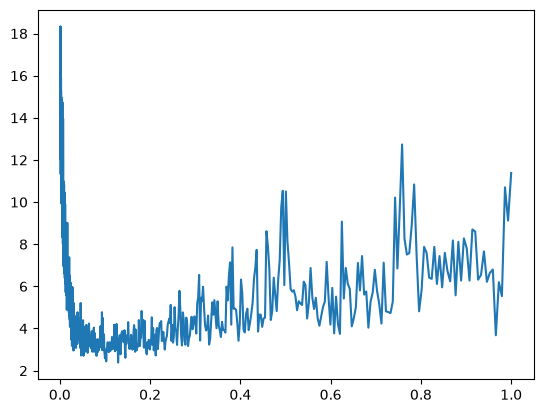

In [114]:
plt.plot(lri,lossi)

In [66]:
torch.randint(0, X.shape[0], (32,))


tensor([153318, 193205, 129652,  65946, 210070,  80965, 197447,  50226,  56339,
        189067, 147521, 124739,  51129, 151622,  27858, 202798, 208687,    149,
        180351, 140075,  22399,  68770, 170224, 146378, 227581, 217121, 204029,
        116719,  27578,  93436, 164716, 181022])